# Executive Summary

This notebook summarizes the bankruptcy prediction project and presents key findings for business stakeholders.

Questions answered:

- How well does the model perform?
- Which financial indicators matter most?
- How many companies are high risk?
- What recommendations can be made?

In [1]:
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

%matplotlib inline

# Load Scored Dataset

In [2]:
df = pd.read_csv(
    "../data/bankruptcy_risk_scored.csv"
)

print(df.shape)

df.head()

(43405, 28)


,A27,A24,A42,A41,A26,A22,A13,A16,A46,A15,...,A18,A38,A11,A14,A7,A1,A51,Bankrupt,Bankruptcy_Probability,Risk_Level
0,1.45820,0.47706,0.128040,0.051402,0.60411,0.21402,0.166600,0.73378,1.52250,497.42,...,0.249760,0.50591,0.249760,0.249760,0.249760,0.200550,0.37854,0.0,0.006241,Low Risk
1,88.44400,0.15510,0.145950,0.064371,0.43992,0.24806,0.158350,0.53838,1.12520,677.96,...,0.258340,0.49788,0.261140,0.258340,0.258340,0.209120,0.49988,0.0,0.089291,Low Risk
2,86.01100,0.15510,0.231170,0.074020,0.37282,0.30260,0.244350,0.45961,1.01010,794.16,...,0.309060,0.51537,0.312580,0.309060,0.309060,0.248660,0.48152,0.0,0.074379,Low Risk
3,0.94076,0.17193,0.088995,0.069622,0.36152,0.11550,0.094257,0.39803,1.56960,917.01,...,0.092704,0.57353,0.092704,0.092704,0.092704,0.081483,0.30734,0.0,0.003038,Low Risk
4,1.41380,0.18732,0.122310,0.096680,0.32211,0.19832,0.121820,0.32211,0.95787,1133.20,...,0.187320,0.43489,0.187320,0.187320,0.187320,0.187320,0.56511,0.0,0.049888,Low Risk


# Dataset Overview

In [3]:
overview = pd.DataFrame({
    "Metric": [
        "Total Companies",
        "Features Used",
        "Bankrupt Companies",
        "Healthy Companies"
    ],
    "Value": [
        len(df),
        df.shape[1] - 3,
        int(df["Bankrupt"].sum()),
        int((df["Bankrupt"] == 0).sum())
    ]
})

overview

,Metric,Value
0,Total Companies,43405
1,Features Used,25
2,Bankrupt Companies,2091
3,Healthy Companies,41314


# Risk Segment Summary

In [4]:
risk_summary = (
    df["Risk_Level"]
    .value_counts()
    .reset_index()
)

risk_summary.columns = [
    "Risk Level",
    "Count"
]

risk_summary

,Risk Level,Count
0,Low Risk,36701
1,Medium Risk,3191
2,High Risk,1913


In [ ]:
# Risk Segment Chart

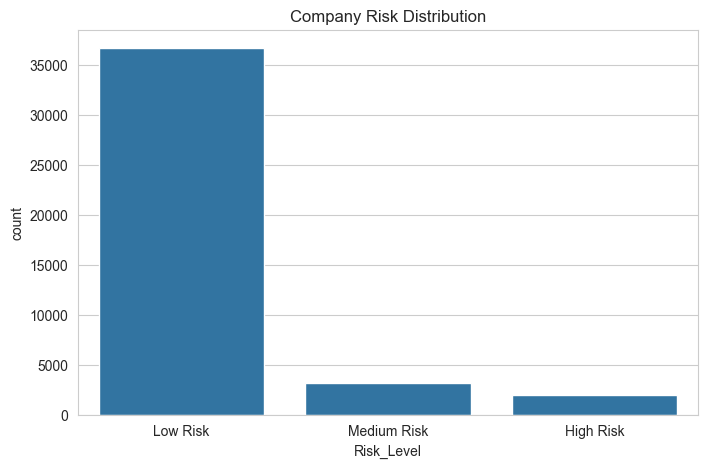

In [5]:
plt.figure(
    figsize=(8,5)
)

sns.countplot(
    x="Risk_Level",
    data=df,
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title(
    "Company Risk Distribution"
)

plt.show()

# Risk Segment Percentages

In [6]:
risk_pct = (
    df["Risk_Level"]
    .value_counts(normalize=True)
    * 100
)

risk_pct.round(2)

Risk_Level
Low Risk       87.79
Medium Risk     7.63
High Risk       4.58
Name: proportion, dtype: float64

# Top Features

In [7]:
top_features = pd.DataFrame({
    "Feature": [
        "A27",
        "A24",
        "A46",
        "A26",
        "A6",
        "A13",
        "A16",
        "A35",
        "A39",
        "A25"
    ],
    "Importance": [
        0.140933,
        0.093404,
        0.060975,
        0.058562,
        0.049332,
        0.047885,
        0.046787,
        0.039467,
        0.039350,
        0.038262
    ]
})

top_features

,Feature,Importance
0,A27,0.140933
1,A24,0.093404
2,A46,0.060975
3,A26,0.058562
4,A6,0.049332
5,A13,0.047885
6,A16,0.046787
7,A35,0.039467
8,A39,0.039350
9,A25,0.038262


In [ ]:
# Top Predictor Chart

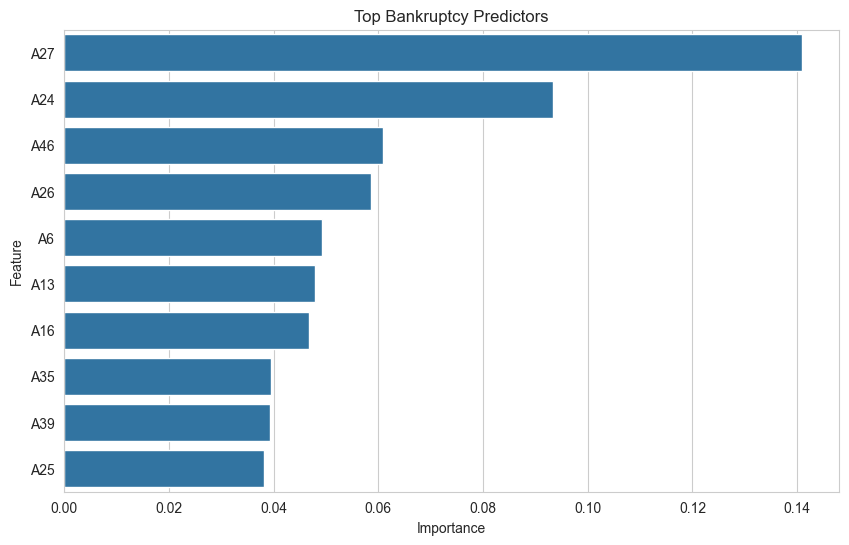

In [8]:
plt.figure(
    figsize=(10,6)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Bankruptcy Predictors"
)

plt.show()

# Average Risk Score

In [9]:
avg_risk = (
    df["Bankruptcy_Probability"]
    .mean()
)

print(
    f"Average Bankruptcy Risk: {avg_risk:.3f}"
)

Average Bankruptcy Risk: 0.133


# Highest Risk Companies

In [10]:
df.sort_values(
    "Bankruptcy_Probability",
    ascending=False
).head(10)[[
    "Bankruptcy_Probability",
    "Risk_Level"
]]

,Bankruptcy_Probability,Risk_Level
27554,0.999946,High Risk
43140,0.999704,High Risk
16993,0.998705,High Risk
27460,0.998598,High Risk
37267,0.998381,High Risk
43150,0.998256,High Risk
37337,0.998242,High Risk
27483,0.998241,High Risk
37294,0.998135,High Risk
27663,0.998135,High Risk


# Risk Score Distribution

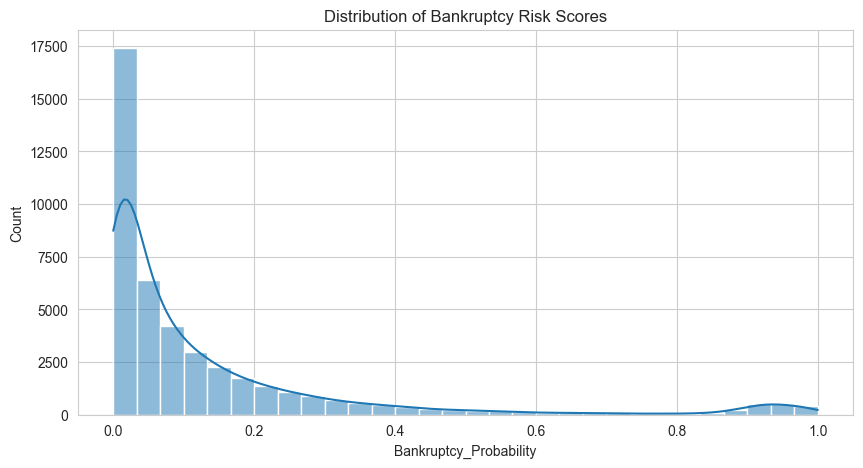

In [11]:
plt.figure(
    figsize=(10,5)
)

sns.histplot(
    df["Bankruptcy_Probability"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Bankruptcy Risk Scores"
)

plt.show()

# Business Recommendations

In [12]:
recommendations = pd.DataFrame({
    "Recommendation": [
        "Monitor High Risk Firms",
        "Quarterly Financial Review",
        "Investigate A27 Indicator",
        "Enhance Early Warning System",
        "Use Model As Screening Tool"
    ]
})

recommendations

,Recommendation
0,Monitor High Risk Firms
1,Quarterly Financial Review
2,Investigate A27 Indicator
3,Enhance Early Warning System
4,Use Model As Screening Tool


# Final Project Summary

In [13]:
project_summary = pd.DataFrame({
    "Metric": [
        "Best Model",
        "ROC-AUC",
        "Recall",
        "F1 Score",
        "High Risk Companies"
    ],
    "Value": [
        "Random Forest",
        "0.905",
        "0.470",
        "0.450",
        1913
    ]
})

project_summary

,Metric,Value
0,Best Model,Random Forest
1,ROC-AUC,0.905
2,Recall,0.470
3,F1 Score,0.450
4,High Risk Companies,1913


## Conclusion

The Random Forest model achieved a ROC-AUC score of 0.905 and successfully identified nearly half of all bankrupt companies.

Feature importance analysis revealed that A27, A24, and A46 were the strongest bankruptcy indicators.

Risk segmentation identified 1,913 companies as high risk, making the model suitable as an early warning financial risk assessment tool.

Future work may include:
- XGBoost
- LightGBM
- SHAP Explainability
- Time-series bankruptcy forecasting